# UHPC: Feature Grouping, SHAP & Permutation Feature Importance

This notebook analyzes model decision drivers using domain feature grouping:
- Feature group mapping into 6 material domains (Binders, Fillers, Fibers, Curing, Water, Admixtures)
- Aggregated SHAP feature attributions at raw feature and domain group levels
- Repeated Group Permutation Feature Importance (RMSE drop over 10 repeats)
- Side-by-side visual comparison of SHAP vs. Permutation feature importance

# UHPC

## Data Loading & Feature Isolation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split, LeaveOneGroupOut, GridSearchCV, GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from pipeline import preprocessing_pipeline

# 50-feature dataset
df_drop = pd.read_csv(".//initial_data_preparation/Datasets/processed/uhpc_dataset/semantic_recoding_features_50.csv")

# Apply drops 
df_drop = df_drop.drop(columns=['cement_grade'])
fiber_cols = ['fiber1_length', 'fiber1_diameter']  
df_drop[fiber_cols] = df_drop[fiber_cols].fillna(0) 

groups = df_drop['publication']

# Proceed to split data
Y = df_drop['cs_28d'] 
X = df_drop.drop(columns=['cs_28d', 'publication'])

C:\Users\jasur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Identify columns for encoding

In [2]:
# Identify all categorical columns
str_cols = X.select_dtypes(include=['object', 'string']).columns

# Sort text columns into One-Hot (<= 10 cat-s) and Target Encoding (> 10 cat-s)
one_hot_encode_cols = str_cols[X[str_cols].nunique() <= 10].tolist()
target_encode_cols = str_cols[X[str_cols].nunique() > 10].tolist()

# Identify all numeric columns
numeric_features = X.select_dtypes(include='number').columns.tolist()

# Print them out to verify
print(f"One-Hot columns: {len(one_hot_encode_cols)}")
print(f"Target Encoded columns: {len(target_encode_cols)}")
print(f"Numeric columns: {len(numeric_features)}")

One-Hot columns: 5
Target Encoded columns: 4
Numeric columns: 24


## Split: Train, Validation, Test

In [3]:
# 1st split: Separate Test (15%) from the rest (85%)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
trainval_idx, test_idx = next(gss1.split(X, Y, groups=groups))

X_trainval = X.iloc[trainval_idx]
Y_trainval = Y.iloc[trainval_idx]
groups_trainval = groups.iloc[trainval_idx]

X_test = X.iloc[test_idx]
Y_test = Y.iloc[test_idx]

# 2nd split: Separate Validation (15%) from Train (70%) 
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.18, random_state=42)
train_idx, val_idx = next(gss2.split(X_trainval, Y_trainval, groups=groups_trainval))

X_train = X_trainval.iloc[train_idx]
Y_train = Y_trainval.iloc[train_idx]

X_val = X_trainval.iloc[val_idx]
Y_val = Y_trainval.iloc[val_idx]

print(f"Train rows: {len(X_train)}")
print(f"Validation rows: {len(X_val)}")
print(f"Test rows: {len(X_test)}")
print(f"Total: {len(X_train) + len(X_val) + len(X_test)}")

Train rows: 1459
Validation rows: 331
Test rows: 283
Total: 2073


## Applying GridSearchCV 

In [8]:
# Define the base models
models = {
    'XGBoost': XGBRegressor(random_state=42),
    'HistGradient': HistGradientBoostingRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42)
}

# Define the parameter grids. 
param_grids = {
    'XGBoost': {
        'model__n_estimators': [50, 100, 200, 500],
        'model__max_depth': [3, 5, 10, 15],
        'model__learning_rate': [0.05, 0.1, 0.2]
    },
    'HistGradient': {
        'model__max_iter': [50, 100, 200, 500],
        'model__max_depth': [3, 5, 10, 15],
        'model__learning_rate': [0.05, 0.1, 0.2]
    },
    'AdaBoost': {
        'model__n_estimators': [50, 100, 200, 500],
        'model__learning_rate': [0.05, 0.1, 0.2]
    }
}

best_pipelines = {}
tuning_results = []

for name, model in models.items():
    
    # Build your custom pipeline
    pipe = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, estimator=model)
    
    # Run GridSearch, using scoring MAE
    gs = GridSearchCV(pipe, param_grids[name], cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    gs.fit(X_train, Y_train)
    
    # Save the best pipeline
    best_pipelines[name] = gs.best_estimator_
    
    # Evaluate it on the Validation
    val_Y_pred = gs.best_estimator_.predict(X_val)
    val_r2 = r2_score(Y_val, val_Y_pred)
    val_rmse = root_mean_squared_error(Y_val, val_Y_pred)
    val_mae = mean_absolute_error(Y_val, val_Y_pred)
    
    tuning_results.append({
        'Model': name,
        'Best Params': gs.best_params_,
        'Val R2': val_r2,
        'Val MAE': val_mae,
        'Val RMSE': val_rmse
    })

tuning_df = pd.DataFrame(tuning_results)[['Model', 'Val R2', 'Val MAE', 'Val RMSE', 'Best Params']]

# Remove the column width limit
pd.set_option('display.max_colwidth', None)
display(tuning_df)

,Model,Val R2,Val MAE,Val RMSE,Best Params
0,XGBoost,0.373188,28.445171,38.936748,"{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 50}"
1,HistGradient,0.399755,29.058639,38.102651,"{'model__learning_rate': 0.2, 'model__max_depth': 15, 'model__max_iter': 50}"
2,AdaBoost,0.359108,29.179042,39.371625,"{'model__learning_rate': 0.1, 'model__n_estimators': 500}"


### Check the total final columns after preprocessing 

In [23]:
# Extract the XGBoost pipeline
preprocessor_check = best_pipelines['XGBoost'].named_steps['preprocessor']

# Get the final column names after One-Hot Encoding
final_columns = preprocessor_check.get_feature_names_out()

print(f"Total columns after all encodings: {len(final_columns)}")

# To print column names
print(final_columns)

Total columns after all encodings: 60
['num__cement' 'num__silica_fume' 'num__fly_ash' 'num__limestone_powder'
 'num__quartz_powder' 'num__glass_powder' 'num__rice_husk_ash'
 'num__metakaolin' 'num__ggbfs' 'num__slag' 'num__nano_caco3'
 'num__nano_al2o3' 'num__nano_tio2' 'num__nano_sio2' 'num__filler'
 'num__sand' 'num__sand_max_size' 'num__fiber1_amount'
 'num__fiber1_length' 'num__fiber1_diameter' 'num__fiber2_amount'
 'num__water' 'num__sp_amount' 'num__curing_temp'
 'ohe__fly_ash_type_class C' 'ohe__fly_ash_type_class F'
 'ohe__fly_ash_type_not_applicable' 'ohe__fly_ash_type_unknown_type'
 'ohe__slag_type_Copper Slag' 'ohe__slag_type_Phosphorous Slag'
 'ohe__slag_type_Steel Slag' 'ohe__slag_type_Steel Slag \r\nPowder'
 'ohe__slag_type_not_applicable' 'ohe__slag_type_unknown_type'
 'ohe__fiber2_type_Carbon Fiber' 'ohe__fiber2_type_Cellulose Fiber'
 'ohe__fiber2_type_Hooked Steel Fiber' 'ohe__fiber2_type_PE Fiber'
 'ohe__fiber2_type_PVA Fiber' 'ohe__fiber2_type_Straight Steel Fiber'


# Group Split (Publication Held-Out)

In [24]:
# Hold out 15% of entire publications
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss.split(X, Y, groups=groups))

X_train_group = X.iloc[train_idx]
Y_train_group = Y.iloc[train_idx]
X_test_group = X.iloc[test_idx]
Y_test_group = Y.iloc[test_idx]
groups_train_group = groups.iloc[train_idx]

# Create a validation set from the remaining training data for conformal calibration
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.18, random_state=42)
train_idx_fin, val_idx = next(gss_val.split(X_train_group, Y_train_group, groups=groups_train_group))

X_train_group_fin = X_train_group.iloc[train_idx_fin]
Y_train_group_fin = Y_train_group.iloc[train_idx_fin]
X_val_group = X_train_group.iloc[val_idx]
Y_val_group = Y_train_group.iloc[val_idx]

group_results = []

for name, pipe in best_pipelines.items():
    # Fit the best tuned pipeline on the training data
    pipe.fit(X_train_group_fin, Y_train_group_fin)
    Y_pred_val = pipe.predict(X_val_group)
    Y_pred_test = pipe.predict(X_test_group)
    
    r2 = r2_score(Y_test_group, Y_pred_test)
    rmse = root_mean_squared_error(Y_test_group, Y_pred_test)
    mae = mean_absolute_error(Y_test_group, Y_pred_test)
    
    residuals = Y_val_group.values - Y_pred_val
    mean_residual = np.mean(residuals)
    direction = "Over-predicting" if mean_residual < 0 else "Under-predicting"
    worst_error = np.max(np.abs(residuals))
    
    # Conformal interval
    perc = np.percentile(np.abs(residuals), 90)
    Y_pred_test_lower = Y_pred_test - perc
    Y_pred_test_upper = Y_pred_test + perc
    
    coverage = np.mean((Y_pred_test_lower <= Y_test_group) & (Y_test_group <= Y_pred_test_upper)) * 100
    avg_width = np.mean(Y_pred_test_upper - Y_pred_test_lower)
    
    group_results.append({
        'Model': name,
        'MAE (MPa)': mae,
        'RMSE (MPa)': rmse,
        'R2': r2,
        'Conformal Coverage %': coverage,
        'Avg Width (MPa)': avg_width,
        'Worst Error (MPa)': worst_error
    })

group_df = pd.DataFrame(group_results)
display(group_df)


,Model,MAE (MPa),RMSE (MPa),R2,Conformal Coverage %,Avg Width (MPa),Worst Error (MPa)
0,XGBoost,15.649093,20.243355,0.545428,100.000000,143.687195,122.090439
1,HistGradient,18.054315,23.540692,0.385281,99.293286,138.267241,108.548709
2,AdaBoost,18.312084,22.164508,0.455053,100.000000,142.469448,131.355238


### Leave one publication group out + Quantile Boosting 


In [25]:
publication_lopo_all = []

# Initialize ALL tracking lists
publications = []
Y_true_all = []

# HistGradient tracking
Y_pred_all_hist = []
Y_lower_all_hist = []
Y_upper_all_hist = []

# XGBoost tracking
Y_pred_all_xgb = []
Y_lower_all_xgb = []
Y_upper_all_xgb = []

#AdaBoost tracking
Y_pred_all_ada = []

# Find publications with >= 50 rows
pub_counts = groups.value_counts()
eligible_pubs = pub_counts[pub_counts >= 50].index.tolist()
print(f"Eligible publications (>=50 rows): {eligible_pubs}")

lopo_results = []

# Leave-One-Out Loop
for publ_name in eligible_pubs:
    
    # Create masks to isolate the specific publication
    test_mask = groups == publ_name
    train_mask = groups != publ_name
    X_train_lopo = X[train_mask]
    X_test_lopo = X[test_mask]
    Y_train_lopo = Y[train_mask]
    Y_test_lopo = Y[test_mask]

    # Get the publication groups for the training data
    groups_train_lopo = groups[train_mask]

    # Create a validation set from the remaining training data
    gss_lopo = GroupShuffleSplit(n_splits=1, test_size=0.18, random_state=42)
    train_idx, val_idx = next(gss_lopo.split(X_train_lopo, Y_train_lopo, groups=groups_train_lopo))
    
    # Final data for this loop
    X_train_lopo_fin = X_train_lopo.iloc[train_idx]
    Y_train_lopo_fin = Y_train_lopo.iloc[train_idx]
    X_val_lopo = X_train_lopo.iloc[val_idx]
    Y_val_lopo = Y_train_lopo.iloc[val_idx]
    
    # Predict using best pipelines
    for name, pipe in best_pipelines.items():
        
        # Fit the best tuned pipeline on the training data
        pipe.fit(X_train_lopo_fin, Y_train_lopo_fin)
        Y_pred_val = pipe.predict(X_val_lopo)
        Y_pred_test = pipe.predict(X_test_lopo)
        r2 = r2_score(Y_test_lopo, Y_pred_test)
        rmse = root_mean_squared_error(Y_test_lopo, Y_pred_test)
        mae = mean_absolute_error(Y_test_lopo, Y_pred_test)
        
        residuals = Y_val_lopo.values - Y_pred_val
        mean_residual = np.mean(residuals)
        direction = "Over-predicting" if mean_residual < 0 else "Under-predicting"
        worst_error = np.max(np.abs(residuals))
        
        # Conformal interval
        # Compute percentile for the current split
        perc = np.percentile(np.abs(residuals), 90)

        # Identify lower and upper bounds 
        Y_pred_test_lower = Y_pred_test - perc
        Y_pred_test_upper = Y_pred_test + perc
        
        # Evaluate coverage of true values with the interval
        coverage_mask_90 =  (Y_pred_test_lower <= Y_test_lopo) & (Y_test_lopo <= Y_pred_test_upper)
        coverage = np.mean(coverage_mask_90)*100

        lopo_results.append({
            'Publication': publ_name,
            'Model': name,
            'Rows': test_mask.sum(),
            'R2': r2,
            'MAE': mae,
            'RMSE': rmse,
            'Direction': direction,
            'Mean_residual': mean_residual,
            'Worst_Error_MPa': round(worst_error, 2),
            'Conformal_Coverage_%': coverage
        })

        if name == 'HistGradient':
            # Track predictions
            publications.extend([publ_name] * len(Y_test_lopo))
            Y_true_all.extend(Y_test_lopo.tolist())
            Y_pred_all_hist.extend(Y_pred_test.tolist())

            # Generate and track quantile boundaries
            best_params_hist = pipe.named_steps['model'].get_params()
            best_params_hist.pop('loss', None)
            best_params_hist.pop('quantile', None)

            pipe_lower_hist = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                                estimator=HistGradientBoostingRegressor(loss='quantile', quantile=0.05, **best_params_hist))
            pipe_upper_hist = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                                estimator=HistGradientBoostingRegressor(loss='quantile', quantile=0.95, **best_params_hist))
            
            pipe_lower_hist.fit(X_train_lopo_fin, Y_train_lopo_fin)
            pipe_upper_hist.fit(X_train_lopo_fin, Y_train_lopo_fin)
            
            Y_lower_all_hist.extend(pipe_lower_hist.predict(X_test_lopo).tolist())
            Y_upper_all_hist.extend(pipe_upper_hist.predict(X_test_lopo).tolist())

        elif name == 'XGBoost':
            # Track predictions
            Y_pred_all_xgb.extend(Y_pred_test.tolist())

            # Generate and track quantile boundaries
            best_params_xgb = pipe.named_steps['model'].get_params()
            
            # Pop 2 parameters then assing then in pipeline call
            best_params_xgb.pop('objective', None)
            best_params_xgb.pop('quantile_alpha', None)

            pipe_lower_xgb = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                                estimator=XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.05, **best_params_xgb))
            pipe_upper_xgb = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                                estimator=XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.95, **best_params_xgb))
            
            pipe_lower_xgb.fit(X_train_lopo_fin, Y_train_lopo_fin)
            pipe_upper_xgb.fit(X_train_lopo_fin, Y_train_lopo_fin)
            
            Y_lower_all_xgb.extend(pipe_lower_xgb.predict(X_test_lopo).tolist())
            Y_upper_all_xgb.extend(pipe_upper_xgb.predict(X_test_lopo).tolist())
        
        elif name == 'AdaBoost':
            Y_pred_all_ada.extend(Y_pred_test.tolist())

lopo_df = pd.DataFrame(lopo_results)
display(lopo_df)


Eligible publications (>=50 rows): ['Ref-144-Research', 'Ref-121-Research', 'Ref-141-Research', 'Ref-48-Research', 'Ref-85-Research', 'Ref-139-Research']


,Publication,Model,Rows,R2,MAE,RMSE,Direction,Mean_residual,Worst_Error_MPa,Conformal_Coverage_%
0,Ref-144-Research,XGBoost,112,0.535335,16.135933,20.403158,Over-predicting,-4.035136,55.02,90.178571
1,Ref-144-Research,HistGradient,112,0.555491,16.362178,19.955728,Over-predicting,-2.635776,74.07,92.857143
2,Ref-144-Research,AdaBoost,112,0.318365,19.163052,24.711730,Over-predicting,-4.196588,65.14,87.500000
3,Ref-121-Research,XGBoost,80,0.510801,16.576217,20.331813,Over-predicting,-6.810382,61.13,96.250000
4,Ref-121-Research,HistGradient,80,0.435222,18.090336,21.846005,Over-predicting,-8.434516,75.28,95.000000
5,Ref-121-Research,AdaBoost,80,0.075728,23.018959,27.946878,Over-predicting,-8.181252,70.47,87.500000
6,Ref-141-Research,XGBoost,73,-1.012005,13.780686,17.711607,Over-predicting,-5.251678,82.50,94.520548
7,Ref-141-Research,HistGradient,73,0.259536,8.971503,10.744725,Over-predicting,-4.213486,72.61,100.000000
8,Ref-141-Research,AdaBoost,73,-0.171836,11.426341,13.516890,Over-predicting,-6.113913,66.25,100.000000
9,Ref-48-Research,XGBoost,72,0.065521,22.666022,27.337455,Over-predicting,-3.423611,68.71,81.944444


Publications 48 and 85 are the worst performers in terms of MAE and RMSE.
 
Comparing the MAE and Mean Residual shows that the error is not systematic, implying that outliers significantly influence the predictions.

### Average LOPO

In [26]:
lopo_avg = lopo_df.groupby('Model')[['MAE', 'RMSE', 'R2', 'Conformal_Coverage_%']].mean()
display(lopo_avg)

,MAE,RMSE,R2,Conformal_Coverage_%
Model,,,,
AdaBoost,21.410009,26.402335,-0.189523,84.555419
HistGradient,18.506214,22.749753,0.103914,88.533108
XGBoost,18.989892,24.134398,-0.103046,86.518821


In [27]:
#Pooled
Y_true_pooled = np.asarray(Y_true_all)

pooled_results = pd.DataFrame([
    {
        "Model": "HistGradient",
        "MAE": mean_absolute_error(
            Y_true_pooled,
            np.asarray(Y_pred_all_hist)
        ),
        "RMSE": root_mean_squared_error(
            Y_true_pooled,
            np.asarray(Y_pred_all_hist)
        ),
        "R2": r2_score(
            Y_true_pooled,
            np.asarray(Y_pred_all_hist)
        )
    },
    {
        "Model": "XGBoost",
        "MAE": mean_absolute_error(
            Y_true_pooled,
            np.asarray(Y_pred_all_xgb)
        ),
        "RMSE": root_mean_squared_error(
            Y_true_pooled,
            np.asarray(Y_pred_all_xgb)
        ),
        "R2": r2_score(
            Y_true_pooled,
            np.asarray(Y_pred_all_xgb)
        )
    },
    {
        "Model": "AdaBoost",
        "MAE": mean_absolute_error(Y_true_pooled, np.asarray(Y_pred_all_ada)),
        "RMSE": root_mean_squared_error(Y_true_pooled, np.asarray(Y_pred_all_ada)),
        "R2": r2_score(Y_true_pooled, np.asarray(Y_pred_all_ada))
    }
])

display(pooled_results)

,Model,MAE,RMSE,R2
0,HistGradient,18.047230,23.312174,0.484075
1,XGBoost,18.692961,24.409975,0.434340
2,AdaBoost,21.140944,26.818179,0.317222


In [28]:
lopo_fold_summary = (
    lopo_df
    .groupby("Model")
    .agg(
        Publications=("Publication", "nunique"),
        Median_R2=("R2", "median"),
        Mean_R2=("R2", "mean"),
        R2_Std=("R2", "std"),
        Median_MAE=("MAE", "median"),
        Median_RMSE=("RMSE", "median")
    )
)

display(lopo_fold_summary)

,Publications,Median_R2,Mean_R2,R2_Std,Median_MAE,Median_RMSE
Model,,,,,,
AdaBoost,6,-0.178796,-0.189523,0.414003,21.871990,27.632677
HistGradient,6,0.300510,0.103914,0.466188,17.819965,22.397319
XGBoost,6,-0.076086,-0.103046,0.601642,16.356075,21.099622


,Publication,Test_Samples,Avg_True_Strength,Hist_Avg_Width,Hist_Coverage,XGB_Avg_Width,XGB_Coverage,Hist_Status,XGB_Status
0,Ref-121-Research,80,165.08,58.97,68.75,87.16,95.00,Undercoverage,Near 90% target
1,Ref-139-Research,51,134.10,47.82,72.55,65.11,90.20,Undercoverage,Near 90% target
2,Ref-141-Research,73,132.51,31.99,87.67,64.82,95.89,Near 90% target,Conservative
3,Ref-144-Research,112,157.05,53.36,75.89,74.82,83.93,Undercoverage,Undercoverage
4,Ref-48-Research,72,188.10,53.80,38.89,70.07,54.17,Undercoverage,Undercoverage
5,Ref-85-Research,64,173.25,48.34,54.69,65.21,54.69,Undercoverage,Undercoverage


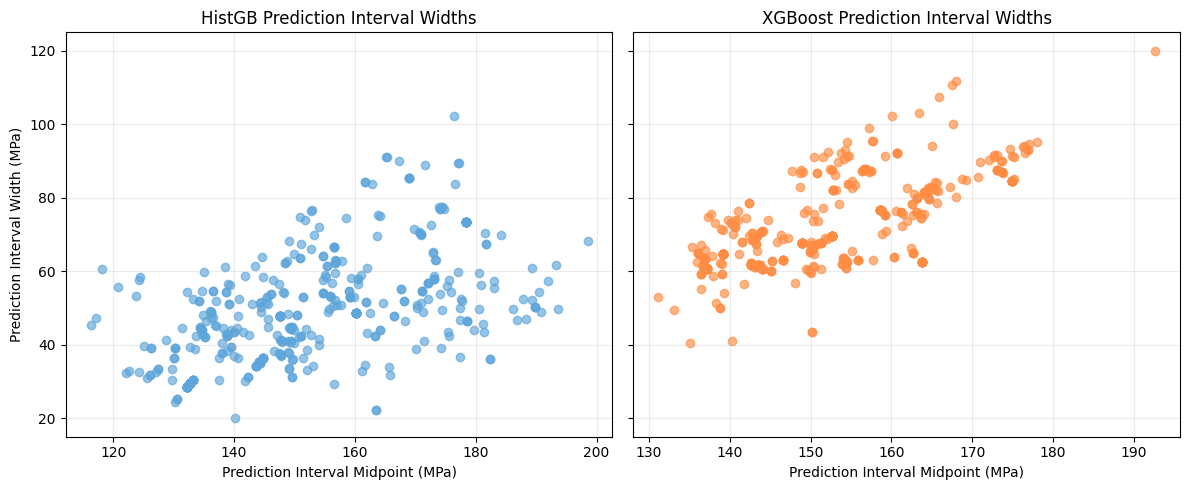

In [29]:
# Build pooled sample-level LOPO DataFrame

df_results = pd.DataFrame({
    "Publication": publications,
    "Y_true": Y_true_all,

    "Hist_Lower": Y_lower_all_hist,
    "Hist_Upper": Y_upper_all_hist,

    "XGB_Lower": Y_lower_all_xgb,
    "XGB_Upper": Y_upper_all_xgb
})


# Use interval midpoint as the central prediction for plotting
df_results["Hist_Interval_Center"] = (
    df_results["Hist_Lower"] +
    df_results["Hist_Upper"]
) / 2

df_results["XGB_Interval_Center"] = (
    df_results["XGB_Lower"] +
    df_results["XGB_Upper"]
) / 2


# Calculate interval widths

df_results["Hist_Width"] = (
    df_results["Hist_Upper"] -
    df_results["Hist_Lower"]
)

df_results["XGB_Width"] = (
    df_results["XGB_Upper"] -
    df_results["XGB_Lower"]
)


# Determine whether each true value is covered

df_results["Hist_Covered"] = (
    (df_results["Hist_Lower"] <= df_results["Y_true"]) &
    (df_results["Y_true"] <= df_results["Hist_Upper"])
)

df_results["XGB_Covered"] = (
    (df_results["XGB_Lower"] <= df_results["Y_true"]) &
    (df_results["Y_true"] <= df_results["XGB_Upper"])
)


# Publication-level calibration table

calibration_table = (
    df_results
    .groupby("Publication")
    .agg(
        Test_Samples=("Y_true", "size"),
        Avg_True_Strength=("Y_true", "mean"),

        Hist_Avg_Width=("Hist_Width", "mean"),
        Hist_Coverage=(
            "Hist_Covered",
            lambda x: x.mean() * 100
        ),

        XGB_Avg_Width=("XGB_Width", "mean"),
        XGB_Coverage=(
            "XGB_Covered",
            lambda x: x.mean() * 100
        )
    )
    .reset_index()
)


# Descriptive calibration labels

def label_calibration(coverage_pct):
    if coverage_pct < 85:
        return "Undercoverage"
    elif coverage_pct > 95:
        return "Conservative"
    else:
        return "Near 90% target"


calibration_table["Hist_Status"] = (
    calibration_table["Hist_Coverage"]
    .apply(label_calibration)
)

calibration_table["XGB_Status"] = (
    calibration_table["XGB_Coverage"]
    .apply(label_calibration)
)


display(calibration_table.round(2))


# Plot interval width against interval midpoint

fig, axs = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 5)
)


# HistGB
axs[0].scatter(
    df_results["Hist_Interval_Center"],
    df_results["Hist_Width"],
    alpha=0.65,
    color="#5DA5DA"
)

axs[0].set_title("HistGB Prediction Interval Widths")
axs[0].set_xlabel("Prediction Interval Midpoint (MPa)")
axs[0].set_ylabel("Prediction Interval Width (MPa)")
axs[0].grid(alpha=0.25)


# XGBoost
axs[1].scatter(
    df_results["XGB_Interval_Center"],
    df_results["XGB_Width"],
    alpha=0.65,
    color="#FF8C42"
)

axs[1].set_title("XGBoost Prediction Interval Widths")
axs[1].set_xlabel("Prediction Interval Midpoint (MPa)")
axs[1].grid(alpha=0.25)


plt.tight_layout()
plt.show()

## Calibration table

### Calibration + Coverage Analysis 


In [30]:
df_results = pd.DataFrame({
    'Publication': publications,
    'Y_true': Y_true_all,
    'Hist_Pred': Y_pred_all_hist,
    'Hist_Lower': Y_lower_all_hist,
    'Hist_Upper': Y_upper_all_hist,
    'XGB_Pred': Y_pred_all_xgb,
    'XGB_Lower': Y_lower_all_xgb,
    'XGB_Upper': Y_upper_all_xgb
})

# Calculate widths and coverage
df_results['Hist_Width'] = df_results['Hist_Upper'] - df_results['Hist_Lower']
df_results['Hist_Covered'] = (df_results['Hist_Lower'] <= df_results['Y_true']) & (df_results['Y_true'] <= df_results['Hist_Upper'])

df_results['XGB_Width'] = df_results['XGB_Upper'] - df_results['XGB_Lower']
df_results['XGB_Covered'] = (df_results['XGB_Lower'] <= df_results['Y_true']) & (df_results['Y_true'] <= df_results['XGB_Upper'])

# Group by publication to create the Calibration table
calibration_table = df_results.groupby('Publication').agg(
    Avg_True_Strength=('Y_true', 'mean'),
    Hist_Avg_Width=('Hist_Width', 'mean'),
    Hist_Coverage=('Hist_Covered', lambda x: np.mean(x) * 100),
    XGB_Avg_Width=('XGB_Width', 'mean'),
    XGB_Coverage=('XGB_Covered', lambda x: np.mean(x) * 100)
).reset_index()

def label_confidence(coverage_pct):
    if coverage_pct < 85.0:
        return 'Overconfident'
    elif coverage_pct > 95.0:
        return 'Underconfident'
    else:
        return 'Well-Calibrated'

# Apply the labels to both models
calibration_table['Hist_Status'] = calibration_table['Hist_Coverage'].apply(label_confidence)
calibration_table['XGB_Status'] = calibration_table['XGB_Coverage'].apply(label_confidence)

display(calibration_table)

,Publication,Avg_True_Strength,Hist_Avg_Width,Hist_Coverage,XGB_Avg_Width,XGB_Coverage,Hist_Status,XGB_Status
0,Ref-121-Research,165.075000,58.968666,68.750000,87.161629,95.000000,Overconfident,Well-Calibrated
1,Ref-139-Research,134.101961,47.817435,72.549020,65.114313,90.196078,Overconfident,Well-Calibrated
2,Ref-141-Research,132.506849,31.989691,87.671233,64.824589,95.890411,Well-Calibrated,Underconfident
3,Ref-144-Research,157.053571,53.357186,75.892857,74.815947,83.928571,Overconfident,Overconfident
4,Ref-48-Research,188.104167,53.804944,38.888889,70.074285,54.166667,Overconfident,Overconfident
5,Ref-85-Research,173.250000,48.335343,54.687500,65.205012,54.687500,Overconfident,Overconfident


Publications 48 and 85 have poor coverage 

Coverage of 48 with HistGrad is 33% meaning 67% actual values outside the interval.

Publ. 121 has the largest interval width 87 MPa

### Plotting


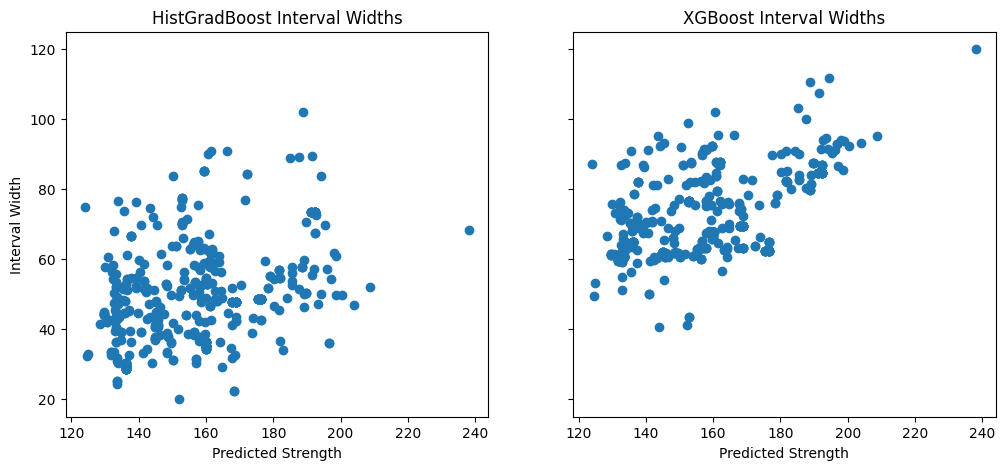

In [31]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(12, 5))

# Plot HistGradient
axs[0].scatter(df_results['XGB_Pred'], df_results['Hist_Width'])
axs[0].set_title('HistGradBoost Interval Widths')
axs[0].set_xlabel('Predicted Strength')
axs[0].set_ylabel('Interval Width')

# Plot XGBoost
axs[1].scatter(df_results['XGB_Pred'], df_results['XGB_Width'])
axs[1].set_title('XGBoost Interval Widths')
axs[1].set_xlabel('Predicted Strength')

plt.show()

XGBoost expands its prediction intervals for extreme recipes. 

HistGradient failed to scale its uncertainty for extreme predictions, resulting in severe overconfidence.

### Random vs Group Publication Split vs LOPO Comparison


In [32]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit

# Using the best parameters 
best_params_xgb = best_pipelines['XGBoost'].named_steps['model'].get_params()
best_params_xgb.pop('objective', None)
best_params_xgb.pop('quantile_alpha', None)

best_params_hist = best_pipelines['HistGradient'].named_steps['model'].get_params()
best_params_hist.pop('loss', None)
best_params_hist.pop('quantile', None)

# Random split

X_train_rand, X_test_rand, Y_train_rand, Y_test_rand = train_test_split(
    X, Y, test_size=0.15, random_state=42
)

# XGBoost
pipe_lower_xgb_rand = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                        estimator=XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.05, **best_params_xgb))
pipe_upper_xgb_rand = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                        estimator=XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.95, **best_params_xgb))

pipe_lower_xgb_rand.fit(X_train_rand, Y_train_rand)
pipe_upper_xgb_rand.fit(X_train_rand, Y_train_rand)

Y_lower_xgb_rand = pipe_lower_xgb_rand.predict(X_test_rand)
Y_upper_xgb_rand = pipe_upper_xgb_rand.predict(X_test_rand)

xgb_width_rand = np.mean(Y_upper_xgb_rand - Y_lower_xgb_rand)
xgb_covered_rand = np.mean((Y_lower_xgb_rand <= Y_test_rand) & (Y_test_rand <= Y_upper_xgb_rand)) * 100

# HistGradient 
pipe_lower_hist_rand = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                        estimator=HistGradientBoostingRegressor(loss='quantile', quantile=0.05, **best_params_hist))
pipe_upper_hist_rand = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                        estimator=HistGradientBoostingRegressor(loss='quantile', quantile=0.95, **best_params_hist))

pipe_lower_hist_rand.fit(X_train_rand, Y_train_rand)
pipe_upper_hist_rand.fit(X_train_rand, Y_train_rand)

Y_lower_hist_rand = pipe_lower_hist_rand.predict(X_test_rand)
Y_upper_hist_rand = pipe_upper_hist_rand.predict(X_test_rand)

hist_width_rand = np.mean(Y_upper_hist_rand - Y_lower_hist_rand)
hist_covered_rand = np.mean((Y_lower_hist_rand <= Y_test_rand) & (Y_test_rand <= Y_upper_hist_rand)) * 100



# Group Split

# Hold out 15% of entire publications
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss.split(X, Y, groups=groups))

X_train_group = X.iloc[train_idx]
Y_train_group = Y.iloc[train_idx]
X_test_group = X.iloc[test_idx]
Y_test_group = Y.iloc[test_idx]

# XGBoost
pipe_lower_xgb_group = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                        estimator=XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.05, **best_params_xgb))
pipe_upper_xgb_group = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                        estimator=XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.95, **best_params_xgb))

pipe_lower_xgb_group.fit(X_train_group, Y_train_group)
pipe_upper_xgb_group.fit(X_train_group, Y_train_group)

Y_lower_xgb_group = pipe_lower_xgb_group.predict(X_test_group)
Y_upper_xgb_group = pipe_upper_xgb_group.predict(X_test_group)

xgb_width_group = np.mean(Y_upper_xgb_group - Y_lower_xgb_group)
xgb_covered_group = np.mean((Y_lower_xgb_group <= Y_test_group) & (Y_test_group <= Y_upper_xgb_group)) * 100

# HistGradient
pipe_lower_hist_group = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                        estimator=HistGradientBoostingRegressor(loss='quantile', quantile=0.05, **best_params_hist))
pipe_upper_hist_group = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                        estimator=HistGradientBoostingRegressor(loss='quantile', quantile=0.95, **best_params_hist))

pipe_lower_hist_group.fit(X_train_group, Y_train_group)
pipe_upper_hist_group.fit(X_train_group, Y_train_group)

Y_lower_hist_group = pipe_lower_hist_group.predict(X_test_group)
Y_upper_hist_group = pipe_upper_hist_group.predict(X_test_group)

hist_width_group = np.mean(Y_upper_hist_group - Y_lower_hist_group)
hist_covered_group = np.mean((Y_lower_hist_group <= Y_test_group) & (Y_test_group <= Y_upper_hist_group)) * 100


# Comparison table
comparison_df = pd.DataFrame({
    'Evaluation Method': [
        'Random Split', 
        'Group Split - Publication Held-Out ', 
        'LOPO'
    ],
    'XGBoost Coverage %': [xgb_covered_rand, xgb_covered_group, calibration_table['XGB_Coverage'].mean()],
    'XGBoost Avg Width MPa': [xgb_width_rand, xgb_width_group, calibration_table['XGB_Avg_Width'].mean()],
    'HistGrad Coverage %': [hist_covered_rand, hist_covered_group, calibration_table['Hist_Coverage'].mean()],
    'HistGrad Avg Width MPa': [hist_width_rand, hist_width_group, calibration_table['Hist_Avg_Width'].mean()]
})

display(comparison_df.round(2))

,Evaluation Method,XGBoost Coverage %,XGBoost Avg Width MPa,HistGrad Coverage %,HistGrad Avg Width MPa
0,Random Split,88.10,68.79,71.70,41.54
1,Group Split - Publication Held-Out,88.69,70.13,78.45,49.53
2,LOPO,78.98,71.20,66.41,49.05


Last version Random + Held-out + LOPO

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import HistGradientBoostingRegressor
from xgboost import XGBRegressor
from IPython.display import display


# Extract tuned model parameters


best_params_xgb = (
    best_pipelines["XGBoost"]
    .named_steps["model"]
    .get_params()
)

best_params_xgb.pop("objective", None)
best_params_xgb.pop("quantile_alpha", None)


best_params_hist = (
    best_pipelines["HistGradient"]
    .named_steps["model"]
    .get_params()
)

best_params_hist.pop("loss", None)
best_params_hist.pop("quantile", None)



# Helper functions

def make_xgb_quantile_pipeline(quantile):
    return preprocessing_pipeline(
        one_hot_encode_cols,
        target_encode_cols,
        numeric_features,
        estimator=XGBRegressor(
            objective="reg:quantileerror",
            quantile_alpha=quantile,
            **best_params_xgb
        )
    )


def make_hist_quantile_pipeline(quantile):
    return preprocessing_pipeline(
        one_hot_encode_cols,
        target_encode_cols,
        numeric_features,
        estimator=HistGradientBoostingRegressor(
            loss="quantile",
            quantile=quantile,
            **best_params_hist
        )
    )


def conformalize_quantile_intervals(
    y_cal,
    lower_cal,
    upper_cal,
    lower_test,
    upper_test,
    alpha=0.10
):
    y_cal = np.asarray(y_cal)

    # Protect against quantile crossing
    cal_low = np.minimum(lower_cal, upper_cal)
    cal_high = np.maximum(lower_cal, upper_cal)

    test_low = np.minimum(lower_test, upper_test)
    test_high = np.maximum(lower_test, upper_test)

    # Nonconformity scores
    scores = np.maximum.reduce([
        cal_low - y_cal,
        y_cal - cal_high,
        np.zeros(len(y_cal))
    ])

    # Finite-sample conformal quantile
    n_cal = len(scores)

    quantile_level = min(
        np.ceil((n_cal + 1) * (1 - alpha)) / n_cal,
        1.0
    )

    q_hat = np.quantile(
        scores,
        quantile_level,
        method="higher"
    )

    lower_conformal = test_low - q_hat
    upper_conformal = test_high + q_hat

    return lower_conformal, upper_conformal, q_hat


def evaluate_quantile_model(
    lower_model,
    upper_model,
    X_fit,
    y_fit,
    X_cal,
    y_cal,
    X_test,
    y_test,
    alpha=0.10
):
    # Train quantile models
    lower_model.fit(X_fit, y_fit)
    upper_model.fit(X_fit, y_fit)

    # Calibration predictions
    lower_cal = lower_model.predict(X_cal)
    upper_cal = upper_model.predict(X_cal)

    # Raw test predictions
    lower_test_raw = lower_model.predict(X_test)
    upper_test_raw = upper_model.predict(X_test)

    # Split-conformal calibration
    lower_test, upper_test, q_hat = (
        conformalize_quantile_intervals(
            y_cal,
            lower_cal,
            upper_cal,
            lower_test_raw,
            upper_test_raw,
            alpha=alpha
        )
    )

    y_test_array = np.asarray(y_test)

    coverage = np.mean(
        (lower_test <= y_test_array) &
        (y_test_array <= upper_test)
    ) * 100

    average_width = np.mean(
        upper_test - lower_test
    )

    return {
        "coverage": coverage,
        "width": average_width,
        "q_hat": q_hat,
        "lower": lower_test,
        "upper": upper_test,
        "y_true": y_test_array
    }


# Random row split

X_train_rand, X_test_rand, Y_train_rand, Y_test_rand = (
    train_test_split(
        X,
        Y,
        test_size=0.15,
        random_state=42
    )
)

# Separate calibration subset
X_fit_rand, X_cal_rand, Y_fit_rand, Y_cal_rand = (
    train_test_split(
        X_train_rand,
        Y_train_rand,
        test_size=0.20,
        random_state=43
    )
)



# Random split: XGBoost


random_xgb_results = evaluate_quantile_model(
    lower_model=make_xgb_quantile_pipeline(0.05),
    upper_model=make_xgb_quantile_pipeline(0.95),
    X_fit=X_fit_rand,
    y_fit=Y_fit_rand,
    X_cal=X_cal_rand,
    y_cal=Y_cal_rand,
    X_test=X_test_rand,
    y_test=Y_test_rand,
    alpha=0.10
)



# Random split: HistGB


random_hist_results = evaluate_quantile_model(
    lower_model=make_hist_quantile_pipeline(0.05),
    upper_model=make_hist_quantile_pipeline(0.95),
    X_fit=X_fit_rand,
    y_fit=Y_fit_rand,
    X_cal=X_cal_rand,
    y_cal=Y_cal_rand,
    X_test=X_test_rand,
    y_test=Y_test_rand,
    alpha=0.10
)


print("Random split results")
print(
    f"XGBoost: coverage = "
    f"{random_xgb_results['coverage']:.2f}%, "
    f"width = {random_xgb_results['width']:.2f} MPa, "
    f"q-hat = {random_xgb_results['q_hat']:.2f} MPa"
)

print(
    f"HistGB: coverage = "
    f"{random_hist_results['coverage']:.2f}%, "
    f"width = {random_hist_results['width']:.2f} MPa, "
    f"q-hat = {random_hist_results['q_hat']:.2f} MPa"
)

Random split results
XGBoost: coverage = 91.32%, width = 71.62 MPa, q-hat = 1.76 MPa
HistGB: coverage = 87.78%, width = 51.93 MPa, q-hat = 5.19 MPa


In [34]:
# Convert publication identifiers to an indexed Series
groups_series = pd.Series(
    np.asarray(groups),
    index=X.index,
    name="Publication"
)


# Outer group split:
# 15% of complete publications are assigned to testing

outer_group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=42
)

train_idx_group, test_idx_group = next(
    outer_group_split.split(
        X,
        Y,
        groups=groups_series
    )
)

X_train_group = X.iloc[train_idx_group]
Y_train_group = Y.iloc[train_idx_group]

X_test_group = X.iloc[test_idx_group]
Y_test_group = Y.iloc[test_idx_group]

groups_train_group = groups_series.iloc[train_idx_group]


# Inner group split:
# complete training publications are assigned to either
# model fitting or conformal calibration

inner_group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=43
)

fit_idx_group, cal_idx_group = next(
    inner_group_split.split(
        X_train_group,
        Y_train_group,
        groups=groups_train_group
    )
)

X_fit_group = X_train_group.iloc[fit_idx_group]
Y_fit_group = Y_train_group.iloc[fit_idx_group]

X_cal_group = X_train_group.iloc[cal_idx_group]
Y_cal_group = Y_train_group.iloc[cal_idx_group]


# Publication group split: XGBoost

group_xgb_results = evaluate_quantile_model(
    lower_model=make_xgb_quantile_pipeline(0.05),
    upper_model=make_xgb_quantile_pipeline(0.95),
    X_fit=X_fit_group,
    y_fit=Y_fit_group,
    X_cal=X_cal_group,
    y_cal=Y_cal_group,
    X_test=X_test_group,
    y_test=Y_test_group,
    alpha=0.10
)


# Publication group split: HistGB

group_hist_results = evaluate_quantile_model(
    lower_model=make_hist_quantile_pipeline(0.05),
    upper_model=make_hist_quantile_pipeline(0.95),
    X_fit=X_fit_group,
    y_fit=Y_fit_group,
    X_cal=X_cal_group,
    y_cal=Y_cal_group,
    X_test=X_test_group,
    y_test=Y_test_group,
    alpha=0.10
)


print("Publication group split results")

print(
    f"XGBoost: coverage = "
    f"{group_xgb_results['coverage']:.2f}%, "
    f"width = {group_xgb_results['width']:.2f} MPa, "
    f"q-hat = {group_xgb_results['q_hat']:.2f} MPa"
)

print(
    f"HistGB: coverage = "
    f"{group_hist_results['coverage']:.2f}%, "
    f"width = {group_hist_results['width']:.2f} MPa, "
    f"q-hat = {group_hist_results['q_hat']:.2f} MPa"
)

print(
    "Test publications:",
    groups_series.iloc[test_idx_group].nunique()
)

Publication group split results
XGBoost: coverage = 98.94%, width = 118.38 MPa, q-hat = 20.88 MPa
HistGB: coverage = 99.29%, width = 112.02 MPa, q-hat = 30.87 MPa
Test publications: 25


In [35]:
# Select publications with more than 50 rows

publication_counts = groups_series.value_counts()

eligible_publications = publication_counts[
    publication_counts > 50
].index.tolist()

print(
    f"Number of eligible LOPO publications: "
    f"{len(eligible_publications)}"
)


# Storage for pooled LOPO predictions

Y_true_lopo_all = []

xgb_lower_lopo_all = []
xgb_upper_lopo_all = []

hist_lower_lopo_all = []
hist_upper_lopo_all = []

lopo_fold_results = []


# LOPO loop

for fold_number, held_out_publication in enumerate(
    eligible_publications,
    start=1
):
    print(
        f"LOPO fold {fold_number}/{len(eligible_publications)}: "
        f"{held_out_publication}"
    )

    # One complete publication is used as the test set
    test_mask = groups_series == held_out_publication

    # Only eligible publications are used for LOPO training
    train_mask = (
        groups_series.isin(eligible_publications) &
        (~test_mask)
    )

    X_train_pool = X.loc[train_mask]
    Y_train_pool = Y.loc[train_mask]
    groups_train_pool = groups_series.loc[train_mask]

    X_test_lopo = X.loc[test_mask]
    Y_test_lopo = Y.loc[test_mask]

    # Need at least two training publications to create
    # separate fitting and calibration subsets
    if groups_train_pool.nunique() < 2:
        print("Skipped: insufficient training publications.")
        continue

    # Group-aware fitting/calibration split
    lopo_calibration_split = GroupShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=42 + fold_number
    )

    fit_idx_lopo, cal_idx_lopo = next(
        lopo_calibration_split.split(
            X_train_pool,
            Y_train_pool,
            groups=groups_train_pool
        )
    )

    X_fit_lopo = X_train_pool.iloc[fit_idx_lopo]
    Y_fit_lopo = Y_train_pool.iloc[fit_idx_lopo]

    X_cal_lopo = X_train_pool.iloc[cal_idx_lopo]
    Y_cal_lopo = Y_train_pool.iloc[cal_idx_lopo]

    # XGBoost

    fold_xgb_results = evaluate_quantile_model(
        lower_model=make_xgb_quantile_pipeline(0.05),
        upper_model=make_xgb_quantile_pipeline(0.95),
        X_fit=X_fit_lopo,
        y_fit=Y_fit_lopo,
        X_cal=X_cal_lopo,
        y_cal=Y_cal_lopo,
        X_test=X_test_lopo,
        y_test=Y_test_lopo,
        alpha=0.10
    )

    # HistGB

    fold_hist_results = evaluate_quantile_model(
        lower_model=make_hist_quantile_pipeline(0.05),
        upper_model=make_hist_quantile_pipeline(0.95),
        X_fit=X_fit_lopo,
        y_fit=Y_fit_lopo,
        X_cal=X_cal_lopo,
        y_cal=Y_cal_lopo,
        X_test=X_test_lopo,
        y_test=Y_test_lopo,
        alpha=0.10
    )

    # Store pooled sample-level results

    Y_true_lopo_all.extend(
        fold_xgb_results["y_true"]
    )

    xgb_lower_lopo_all.extend(
        fold_xgb_results["lower"]
    )

    xgb_upper_lopo_all.extend(
        fold_xgb_results["upper"]
    )

    hist_lower_lopo_all.extend(
        fold_hist_results["lower"]
    )

    hist_upper_lopo_all.extend(
        fold_hist_results["upper"]
    )

    # Store publication-level results for additional analysis
    lopo_fold_results.append({
        "Publication": held_out_publication,
        "Test samples": len(Y_test_lopo),

        "XGBoost Coverage (%)":
            fold_xgb_results["coverage"],

        "XGBoost Avg Width (MPa)":
            fold_xgb_results["width"],

        "XGBoost q-hat (MPa)":
            fold_xgb_results["q_hat"],

        "HistGB Coverage (%)":
            fold_hist_results["coverage"],

        "HistGB Avg Width (MPa)":
            fold_hist_results["width"],

        "HistGB q-hat (MPa)":
            fold_hist_results["q_hat"]
    })


# Pooled LOPO results


Y_true_lopo_all = np.asarray(Y_true_lopo_all)

xgb_lower_lopo_all = np.asarray(xgb_lower_lopo_all)
xgb_upper_lopo_all = np.asarray(xgb_upper_lopo_all)

hist_lower_lopo_all = np.asarray(hist_lower_lopo_all)
hist_upper_lopo_all = np.asarray(hist_upper_lopo_all)


lopo_xgb_coverage = np.mean(
    (xgb_lower_lopo_all <= Y_true_lopo_all) &
    (Y_true_lopo_all <= xgb_upper_lopo_all)
) * 100

lopo_xgb_width = np.mean(
    xgb_upper_lopo_all - xgb_lower_lopo_all
)


lopo_hist_coverage = np.mean(
    (hist_lower_lopo_all <= Y_true_lopo_all) &
    (Y_true_lopo_all <= hist_upper_lopo_all)
) * 100

lopo_hist_width = np.mean(
    hist_upper_lopo_all - hist_lower_lopo_all
)


lopo_xgb_results = {
    "coverage": lopo_xgb_coverage,
    "width": lopo_xgb_width
}

lopo_hist_results = {
    "coverage": lopo_hist_coverage,
    "width": lopo_hist_width
}


# Publication-level table
lopo_fold_df = pd.DataFrame(lopo_fold_results)

display(lopo_fold_df.round(2))


print("Pooled LOPO results")

print(
    f"XGBoost: coverage = "
    f"{lopo_xgb_coverage:.2f}%, "
    f"width = {lopo_xgb_width:.2f} MPa"
)

print(
    f"HistGB: coverage = "
    f"{lopo_hist_coverage:.2f}%, "
    f"width = {lopo_hist_width:.2f} MPa"
)

Number of eligible LOPO publications: 6
LOPO fold 1/6: Ref-144-Research
LOPO fold 2/6: Ref-121-Research
LOPO fold 3/6: Ref-141-Research
LOPO fold 4/6: Ref-48-Research
LOPO fold 5/6: Ref-85-Research
LOPO fold 6/6: Ref-139-Research


,Publication,Test samples,XGBoost Coverage (%),XGBoost Avg Width (MPa),XGBoost q-hat (MPa),HistGB Coverage (%),HistGB Avg Width (MPa),HistGB q-hat (MPa)
0,Ref-144-Research,112,95.54,114.59,28.91,91.07,91.58,23.56
1,Ref-121-Research,80,90.00,121.46,29.83,96.25,136.44,42.29
2,Ref-141-Research,73,100.00,175.99,60.39,100.00,145.56,46.07
3,Ref-48-Research,72,79.17,103.91,22.47,93.06,97.50,23.77
4,Ref-85-Research,64,51.56,60.93,1.60,78.12,98.81,17.76
5,Ref-139-Research,51,74.51,84.11,10.81,80.39,86.88,22.47


Pooled LOPO results
XGBoost: coverage = 84.07%, width = 112.98 MPa
HistGB: coverage = 90.71%, width = 109.68 MPa


,Evaluation Method,XGBoost Coverage (%),XGBoost Avg Width (MPa),HistGB Coverage (%),HistGB Avg Width (MPa)
0,Random Split,91.32,71.62,87.78,51.93
1,Publication Group Split,98.94,118.38,99.29,112.02
2,LOPO (P > 50 rows),84.07,112.98,90.71,109.68


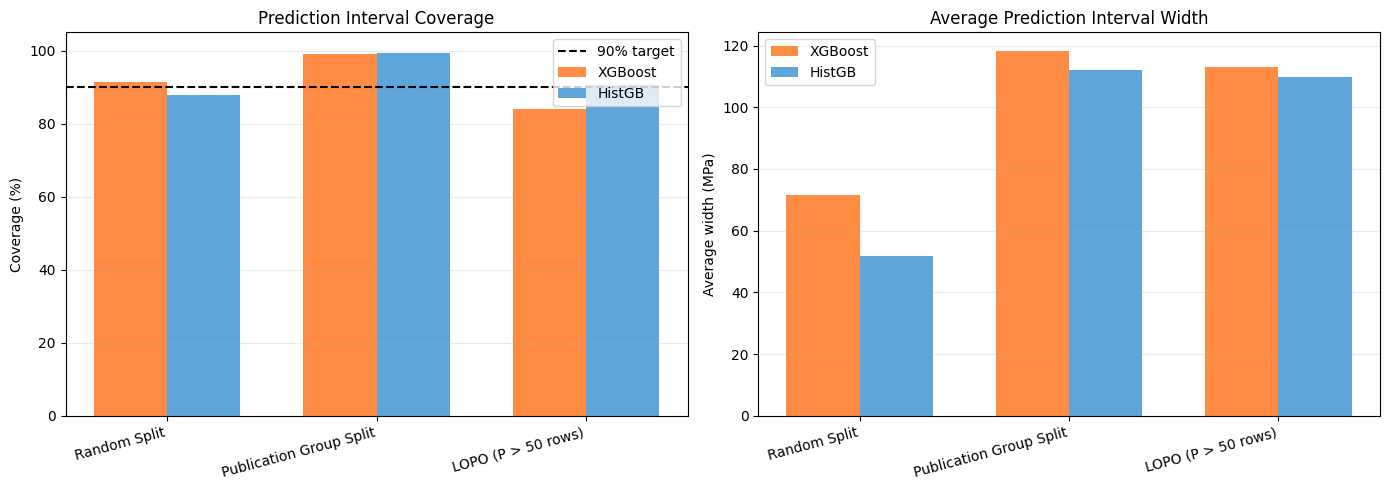

In [36]:
# Final comparison table

comparison_df = pd.DataFrame({
    "Evaluation Method": [
        "Random Split",
        "Publication Group Split",
        "LOPO (P > 50 rows)"
    ],

    "XGBoost Coverage (%)": [
        random_xgb_results["coverage"],
        group_xgb_results["coverage"],
        lopo_xgb_results["coverage"]
    ],

    "XGBoost Avg Width (MPa)": [
        random_xgb_results["width"],
        group_xgb_results["width"],
        lopo_xgb_results["width"]
    ],

    "HistGB Coverage (%)": [
        random_hist_results["coverage"],
        group_hist_results["coverage"],
        lopo_hist_results["coverage"]
    ],

    "HistGB Avg Width (MPa)": [
        random_hist_results["width"],
        group_hist_results["width"],
        lopo_hist_results["width"]
    ]
})

comparison_rounded = comparison_df.round(2)

# Plain display does not require jinja2
display(comparison_rounded)


# Visual comparison

methods = comparison_df["Evaluation Method"]
x = np.arange(len(methods))
bar_width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Coverage
axes[0].bar(
    x - bar_width / 2,
    comparison_df["XGBoost Coverage (%)"],
    width=bar_width,
    label="XGBoost",
    color="#FF8C42"
)

axes[0].bar(
    x + bar_width / 2,
    comparison_df["HistGB Coverage (%)"],
    width=bar_width,
    label="HistGB",
    color="#5DA5DA"
)

axes[0].axhline(
    90,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="90% target"
)

axes[0].set_title("Prediction Interval Coverage")
axes[0].set_ylabel("Coverage (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=15, ha="right")
axes[0].set_ylim(0, 105)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)


# Average interval width
axes[1].bar(
    x - bar_width / 2,
    comparison_df["XGBoost Avg Width (MPa)"],
    width=bar_width,
    label="XGBoost",
    color="#FF8C42"
)

axes[1].bar(
    x + bar_width / 2,
    comparison_df["HistGB Avg Width (MPa)"],
    width=bar_width,
    label="HistGB",
    color="#5DA5DA"
)

axes[1].set_title("Average Prediction Interval Width")
axes[1].set_ylabel("Average width (MPa)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=15, ha="right")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


# Save table if needed
comparison_rounded.to_csv(
    "conformal_interval_comparison.csv",
    index=False
)

### Comparison table

### Apply SHAP (SHapley Additive exPlanations) investigating overconfident failures

d:\Studium\sem3\Project\Da2De\Da2De\S4_Boosting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP Analysis for the max error publication Ref-85-Research
True Concrete Strength:      232.00 MPa
XGBoost Predicted Strength:  158.30 MPa
Absolute Error:              73.70 MPa


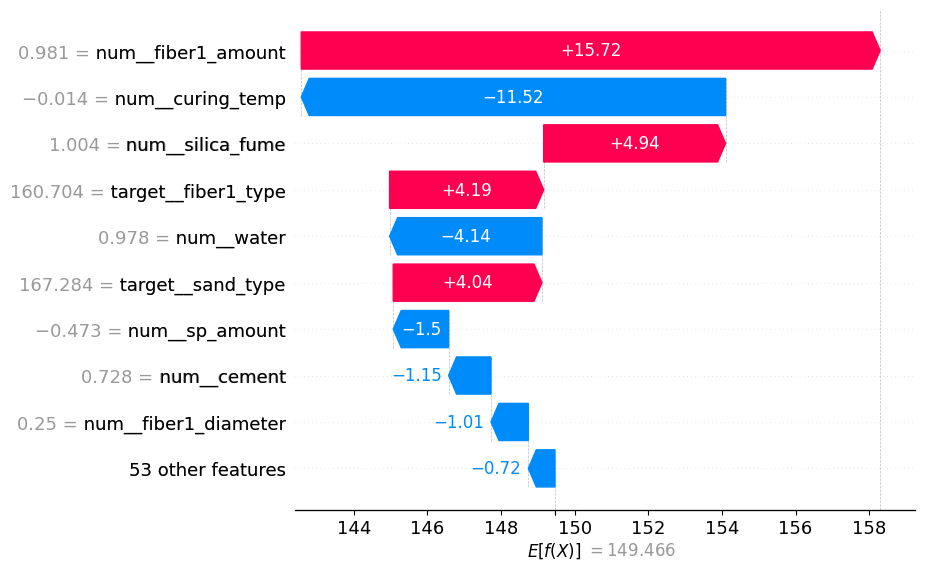

In [37]:

# Isolate the worst-performing publication
target_pub = 'Ref-85-Research'
test_mask = groups == target_pub
train_mask = groups != target_pub

X_train_shap = X[train_mask]
Y_train_shap = Y[train_mask]
X_test_shap = X[test_mask]
Y_test_shap = Y[test_mask]

# Fit the best XGBoost pipeline on this LOPO split
pipe_shap = best_pipelines['XGBoost']
pipe_shap.fit(X_train_shap, Y_train_shap)

# Extract the preprocessor and the actual XGBoost model
preprocessor = pipe_shap.named_steps['preprocessor']
xgb_model = pipe_shap.named_steps['model']

# Transform the test data so SHAP can read the encoded and scaled features
X_test_transformed = preprocessor.transform(X_test_shap)
feature_names = preprocessor.get_feature_names_out()

# Calculate Errors to find the absolute worst prediction
Y_pred_shap = pipe_shap.predict(X_test_shap)
errors = np.abs(Y_test_shap.values - Y_pred_shap)
worst_idx = np.argmax(errors) # Index of the row with the biggest mistake

print(f"SHAP Analysis for the max error publication {target_pub}")
print(f"True Concrete Strength:      {Y_test_shap.values[worst_idx]:.2f} MPa")
print(f"XGBoost Predicted Strength:  {Y_pred_shap[worst_idx]:.2f} MPa")
print(f"Absolute Error:              {errors[worst_idx]:.2f} MPa")

# Initialize SHAP Explainer and calculate values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_transformed)
shap_values.feature_names = feature_names

# Plot the Waterfall chart for the worst prediction
plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_values[worst_idx], max_display=10, show=False)
ax = plt.gca()
ax.tick_params(axis='x', top=False, labeltop=False)
plt.show()

# E[f(X)] is the average prediction 

# Week 10

## Feature group mapping

In [38]:
# Feature group mapping
feature_groups = {
    'Binders & SCMs': [
        'cement', 'cement_type', 'silica_fume', 'fly_ash', 'fly_ash_type', 
        'ggbfs', 'slag', 'slag_type', 'metakaolin', 'rice_husk_ash', 
        'quartz_powder', 'glass_powder', 'limestone_powder', 
        'nano_caco3', 'nano_al2o3', 'nano_tio2', 'nano_sio2'
    ],
    'Fillers & Aggregates': [
        'sand', 'sand_type', 'sand_max_size', 'gravel', 'filler', 'filler_type'
    ],
    'Fibers': [
        'fiber1_amount', 'fiber1_length', 'fiber1_diameter', 'fiber1_type',
        'fiber2_amount', 'fiber2_type'
    ],
    'Curing Conditions': [
        'curing_temp', 'curing_humidity', 'curing_method', 'age'
    ],
    'Water': [
        'water'
    ],
    'Chemical Admixtures': [
        'sp_amount', 'sp_type'
    ]
}

# Mapping with the features in X_test_group
raw_features = list(X_test_group.columns)
clean_feature_groups = {}
raw_to_group = {}

for g_name, f_list in feature_groups.items():
    valid_cols = [c for c in f_list if c in raw_features]
    if valid_cols:
        clean_feature_groups[g_name] = valid_cols
        for col in valid_cols:
            raw_to_group[col] = g_name

print(f"Total raw features mapped: {len(raw_to_group)} to {len(clean_feature_groups)} groups.")

Total raw features mapped: 33 to 6 groups.


In [39]:
# Verify full mapping
unassigned = [c for c in raw_features if c not in raw_to_group]
print(f"Unassigned features left: {len(unassigned)}")

Unassigned features left: 0


## Extract pipeline steps

In [40]:
pipe_xgb = best_pipelines['XGBoost']
preprocessor = pipe_xgb.named_steps['preprocessor']
xgb_model = pipe_xgb.named_steps['model']

# Get the transformed feature array and names
X_test_transformed = preprocessor.transform(X_test_group)
transformed_names = preprocessor.get_feature_names_out()


## Run SHAP and aggregate


In [41]:
explainer = shap.TreeExplainer(xgb_model)
shap_explanation = explainer(X_test_transformed)

# Extract the raw values array
shap_values_matrix = shap_explanation.values

# Initialize raw feature tracking DataFrame
shap_by_raw = pd.DataFrame(0.0, index=X_test_group.index, columns=raw_features)

# Sort raw features by length (descending) to avoid substring matching bugs
sorted_raw_features = sorted(raw_features, key=len, reverse=True)

for col_idx, t_name in enumerate(transformed_names):
    # Strip sklearn pipeline prefixes
    clean_t = t_name.replace('num__', '').replace('ohe__', '').replace('target__', '')
    
    for r_name in sorted_raw_features:
        if clean_t.startswith(r_name):
            shap_by_raw[r_name] += shap_values_matrix[:, col_idx]
            break

# Aggregate raw feature attributions into engineered groups
shap_by_group = pd.DataFrame(0.0, index=X_test_group.index, columns=clean_feature_groups.keys())
for r_name in raw_features:
    g_name = raw_to_group[r_name]
    shap_by_group[g_name] += shap_by_raw[r_name]

# Calculate mean absolute values
feature_shap_importance = shap_by_raw.abs().mean().sort_values(ascending=False)
group_shap_importance = shap_by_group.abs().mean().sort_values(ascending=False)

## Permutation

In [42]:
# Baseline performance assessment
baseline_preds = pipe_xgb.predict(X_test_group)
baseline_rmse = root_mean_squared_error(Y_test_group, baseline_preds)

n_repeats = 10
rng = np.random.default_rng(42)

# Repeated individual feature level permutation
perm_raw_means = {}
perm_raw_stds = {}

for col in raw_features:
    scores = []
    for _ in range(n_repeats):
        X_permuted = X_test_group.copy()
        X_permuted[col] = rng.permutation(X_permuted[col].values)
        
        preds = pipe_xgb.predict(X_permuted)
        scores.append(root_mean_squared_error(Y_test_group, preds) - baseline_rmse)
    
    perm_raw_means[col] = np.mean(scores)
    perm_raw_stds[col] = np.std(scores)

perm_importance_raw_mean = pd.Series(perm_raw_means).sort_values(ascending=False)
perm_importance_raw_std = pd.Series(perm_raw_stds)

# Repeated group level permutation, shuffling columns inside a group together
perm_group_means = {}
perm_group_stds = {}

for group_name, cols_in_group in clean_feature_groups.items():
    scores = []
    for _ in range(n_repeats):
        X_permuted = X_test_group.copy()
        # Ensure all columns in this group are shuffled using the exact same row order
        shuffled_indices = rng.permutation(X_test_group.index)
        
        for col in cols_in_group:
            X_permuted[col] = X_test_group[col].loc[shuffled_indices].values
            
        preds = pipe_xgb.predict(X_permuted)
        scores.append(root_mean_squared_error(Y_test_group, preds) - baseline_rmse)
        
    perm_group_means[group_name] = np.mean(scores)
    perm_group_stds[group_name] = np.std(scores)

perm_importance_group_mean = pd.Series(perm_group_means).sort_values(ascending=False)
perm_importance_group_std = pd.Series(perm_group_stds)

## Summary



Grouped attribution comparison


,SHAP Mean,Permutation Mean RMSE,Permutation Variation (Std)
Curing Conditions,12.8269,13.1753,0.7597
Fibers,8.0586,8.7106,0.6941
Binders & SCMs,6.6965,9.2011,0.9540
Fillers & Aggregates,4.9979,6.2074,0.4762
Water,4.4572,4.0701,0.3765
Chemical Admixtures,0.8895,1.0690,0.0956



 Top10 Individual raw features


,SHAP Mean,Permutation Mean RMSE,Permutation Variation (Std)
curing_temp,12.8498,12.5787,0.9666
fiber1_amount,7.3993,7.4540,0.7709
water,4.4572,3.7329,0.3816
sand_type,3.9360,2.4332,0.3022
cement_type,3.6834,3.8145,0.4990
cement,2.7961,3.2442,0.3055
silica_fume,2.2622,1.5384,0.1748
fiber1_type,1.8342,0.8496,0.1817
glass_powder,1.6176,1.0666,0.1396
sand_max_size,1.5401,1.9197,0.1726


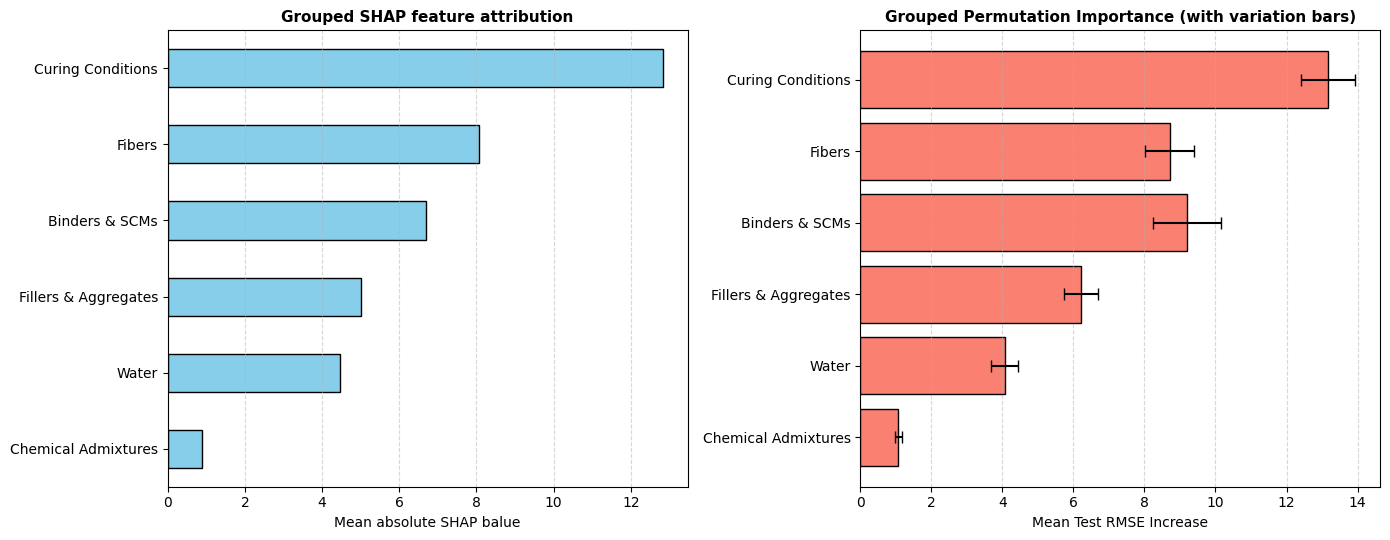

In [43]:
print("\nGrouped attribution comparison")
group_comparison = pd.DataFrame({
    'SHAP Mean': group_shap_importance,
    'Permutation Mean RMSE': perm_importance_group_mean,
    'Permutation Variation (Std)': perm_importance_group_std
}).sort_values(by='SHAP Mean', ascending=False)
display(group_comparison.round(4))

print("\n Top10 Individual raw features")
feature_comparison = pd.DataFrame({
    'SHAP Mean': feature_shap_importance,
    'Permutation Mean RMSE': perm_importance_raw_mean,
    'Permutation Variation (Std)': perm_importance_raw_std
}).sort_values(by='SHAP Mean', ascending=False).head(10)
display(feature_comparison.round(4))

# Generate comparative horizontal bar plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot SHAP
group_shap_importance.plot(kind='barh', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title("Grouped SHAP feature attribution", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Mean absolute SHAP balue")
axes[0].invert_yaxis()
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# Plot Permutation with Error Bars representing variation stability
perm_sorted = perm_importance_group_mean.loc[group_shap_importance.index]
std_sorted = perm_importance_group_std.loc[group_shap_importance.index]

axes[1].barh(perm_sorted.index, perm_sorted.values, xerr=std_sorted.values, color='salmon', edgecolor='black', capsize=4)
axes[1].set_title("Grouped Permutation Importance (with variation bars)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Mean Test RMSE Increase")
axes[1].invert_yaxis()
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()